In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import pandas as pd
import seaborn as sns
import os
import sys
import pickle

In [53]:
data_directory = '/mnt/f/Behavioural_Data/Bpod_data/'
experiment_name = 'D-AP5-Chronic-Infusion-SP120-137_Aug23_Analysis'
data_path = os.path.join(data_directory, experiment_name)
save_path = os.path.join(data_path, 'Figures_and_csv')
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [54]:
# list all the .pkl files in the current directory

pkl_files = [file for file in os.listdir(data_path) if file.endswith('.pkl')]

print(pkl_files)

['D-AP5-Chronic-Infusion-SP120-137_Aug23_dataframe.pkl']


In [55]:
# list pickle files in the data_path and load them as dictionaries
data_file = os.path.join(data_path, pkl_files[0])
with open(data_file, 'rb') as f:
    data = pickle.load(f)
print(data.keys())

Index(['AnimalID', 'ExperimentalGroup', 'SessionTime', 'FullSessionTime',
       'Protocol', 'Stimulation', 'Muscimol', 'RewardChange',
       'RewardChangeBlock', 'CenterPortDuration', 'Contingency',
       'RewardAmount', 'PunishDelay', 'Punish', 'BiasCorrection', 'TrialIndex',
       'TrialHighPerc', 'Outcomes', 'OptoStim', 'FirstPokeCorrect',
       'FirstPoke', 'TrialSide', 'TrialSequence', 'ResponseTime',
       'TrialStartTimestamp', 'CumulativePerformance', 'SwitchSide',
       'PreviousChoice', 'TrialEvents', 'TrialStates', 'FullGUI', 'SessionID',
       'ITIs', 'CumulativeTrialNumber', 'CumulativeTrialNumberByProtocol',
       'CurrentPastPerformance20', 'CurrentPastPerformance100',
       'NoOfCenterPokes', 'MiddleWaitTime', 'TrialInitiationTime', 'RightBias',
       'TrialsSpeed', 'PrevTrialSuccess'],
      dtype='object')


In [56]:
# convert the dictionary to a dataframe
df = pd.DataFrame(data)
df.head()

,AnimalID,ExperimentalGroup,SessionTime,FullSessionTime,Protocol,Stimulation,Muscimol,RewardChange,RewardChangeBlock,CenterPortDuration,...,CumulativeTrialNumber,CumulativeTrialNumberByProtocol,CurrentPastPerformance20,CurrentPastPerformance100,NoOfCenterPokes,MiddleWaitTime,TrialInitiationTime,RightBias,TrialsSpeed,PrevTrialSuccess
0,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,1,1.0,NaN,NaN,1,0.036407,290.7158,NaN,NaN,NaN
14,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,2,2.0,NaN,NaN,1,0.210900,NaN,NaN,NaN,0.0
17,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,3,3.0,NaN,NaN,1,0.349400,38.5954,NaN,1.313154,1.0
27,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,4,4.0,NaN,NaN,1,0.063000,49.1914,NaN,1.756277,1.0
34,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,5,5.0,NaN,NaN,1,0.058800,8.2032,NaN,1.751116,1.0


In [57]:
df.info()
# if 'SP126' in df['AnimalID'].tolist():
#     print("'SP126' exists in the original dataframe.")
# else:
#     print("'SP126' does not exist in the original dataframe.")


<class 'pandas.core.frame.DataFrame'>
Int64Index: 164456 entries, 0 to 179222
Data columns (total 43 columns):
AnimalID                           164456 non-null object
ExperimentalGroup                  164456 non-null object
SessionTime                        164456 non-null object
FullSessionTime                    164456 non-null datetime64[ns]
Protocol                           164456 non-null object
Stimulation                        164456 non-null object
Muscimol                           164456 non-null object
RewardChange                       164456 non-null object
RewardChangeBlock                  164456 non-null int64
CenterPortDuration                 164456 non-null float64
Contingency                        164456 non-null int64
RewardAmount                       164456 non-null int64
PunishDelay                        164456 non-null float64
Punish                             164456 non-null object
BiasCorrection                     164456 non-null int64
TrialIndex   

### last session of chronic D-AP5 treatment vs first session of saline infusion after chronic D-AP5 infusion vs first saline session when animals cross >3000 trials in the saline groups: Task performance (%) 

In [58]:
# print names of ExperimentalGroups
print(df['ExperimentalGroup'].unique())
# replace Control with Saline
df['ExperimentalGroup'] = df['ExperimentalGroup'].replace('Control', 'Saline')
print(df['ExperimentalGroup'].unique())

['D-AP5' 'Control']
['D-AP5' 'Saline']


In [59]:
# define the columns to be plotted
mice = ['SP120', 'SP121', 'SP122', 'SP126', 'SP138', 'SP139', 'SP140'] 
saline_dates = ['2023-06-07', '2023-06-09', '2023-06-08', '2023-06-05', '2023-11-02', '2023-10-23', '2023-10-27']
AP5_dates = ['2023-06-06', '2023-06-08', '2023-06-07', '2023-06-04', '2023-11-01', '2023-10-20', '2023-10-26']

In [60]:

def filter_dataframes(df, mice, saline_dates, AP5_dates):
    """
    Extracts data from saline and AP5 groups from a DataFrame and saves them as separate DataFrames.

    Args:
        df (pd.DataFrame): The input DataFrame.
        mice (list): List of mouse IDs.
        saline_dates (list): List of saline treatment dates corresponding to the mice.
        AP5_dates (list): List of AP5 treatment dates corresponding to the mice.

    Returns:
        tuple: Two DataFrames, saline_df_post_ap5 and last_ap5_df.
    """

    saline_df_post_ap5 = pd.DataFrame()
    last_ap5_df = pd.DataFrame()

    for mouse, saline_date, AP5_date in zip(mice, saline_dates, AP5_dates):
        sessions = df['FullSessionTime'].astype(str).str[:10]

        saline_data = df[(df['AnimalID'] == mouse) & (sessions == saline_date)]
        ap5_data = df[(df['AnimalID'] == mouse) & (sessions == AP5_date)]

        saline_df_post_ap5 = pd.concat([saline_df_post_ap5, saline_data], ignore_index=True)
        last_ap5_df = pd.concat([last_ap5_df, ap5_data], ignore_index=True)

    return saline_df_post_ap5, last_ap5_df



In [61]:

saline_df_post_ap5, last_ap5_df = filter_dataframes(df, mice, saline_dates, AP5_dates)



In [62]:
def perf_window_calculator(firstpokecorrect, window):
    """
    Calculate the performance of the last X trials
    This is a function written by Hernando and used in APE paper (Greenstreet et al., 2022 for analysis)
    """
    perf_window = np.full(len(firstpokecorrect), np.nan)
    for i in range(len(perf_window)):
        if i < window:
            # For the first window-1 trials, dynamically adjust the window size
            current_window_size = i + 1
            perf_window[i] = np.nansum(firstpokecorrect[:i+1]) / current_window_size * 100
        else:
            perf_window[i] = np.nansum(firstpokecorrect[i - window + 1: i + 1]) / window * 100
    return perf_window

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import os

def plot_performance(saline_df, ap5_df, save_path=".", filename="performance_data.csv"):
    """
    Plots the performance of animals grouped by treatment (Saline vs. D-AP5).

    Args:
        saline_df (pd.DataFrame): DataFrame containing saline treatment data.
        ap5_df (pd.DataFrame): DataFrame containing AP5 treatment data.
        save_path (str): Path to save the performance data CSV. Defaults to current directory.
        filename (str): Name of the CSV file to save. Defaults to 'performance_data.csv'.
    """

    saline_df['Treatment'] = 'Saline'
    ap5_df['Treatment'] = 'D-AP5'

    combined_df = pd.concat([saline_df, ap5_df], ignore_index=True)

    # Calculate performance as percentage of FirstPokeCorrect trials
    perf = combined_df.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].sum() / \
           combined_df.groupby(['Treatment', 'AnimalID'])['FirstPokeCorrect'].count() * 100
    perf = perf.reset_index()
    perf.columns = ['Treatment', 'AnimalID', 'Performance']

    print(perf)

    # Save performance data to CSV
    csv_filename = os.path.join(save_path, filename)
    perf.to_csv(csv_filename, index=False)
    print(f"Data saved to '{csv_filename}'")

    # Perform t-test
    saline_perf = perf[perf['Treatment'] == 'Saline']['Performance']
    ap5_perf = perf[perf['Treatment'] == 'D-AP5']['Performance']
    t, p = ttest_ind(saline_perf, ap5_perf)
    print('t-statistic:', t)
    print('p-value:', p)

    # Plot performance
    group_colors = {'Saline': '#808080', 'D-AP5': '#cf2c8b'}
    group_order = ['Saline', 'D-AP5']

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(x='Treatment', y='Performance', data=perf, palette=group_colors, order=group_order, ax=ax)
    sns.swarmplot(x='Treatment', y='Performance', data=perf, color='black', order=group_order, ax=ax)

    ax.set_xlabel('Treatment', fontsize=14)
    ax.set_ylabel('Performance (%)', fontsize=14)
    ax.set_ylim(50, 100)
    ax.tick_params(labelsize=14)
    ax.set_title('Performance', fontsize=16)
    plt.tight_layout()
    plt.show()

   Treatment AnimalID  Performance
0      D-AP5    SP120    81.869688
1      D-AP5    SP121    86.695279
2      D-AP5    SP122    76.190476
3      D-AP5    SP126    66.200000
4      D-AP5    SP138    85.450346
5      D-AP5    SP139    82.317073
6      D-AP5    SP140    62.589928
7     Saline    SP120    85.439560
8     Saline    SP121    80.833333
9     Saline    SP122    80.503145
10    Saline    SP126    70.276008
11    Saline    SP138    88.359788
12    Saline    SP139    91.916168
13    Saline    SP140    65.472313
Data saved to './performance_data.csv'
t-statistic: 0.6029797247175047
p-value: 0.5577465540626678


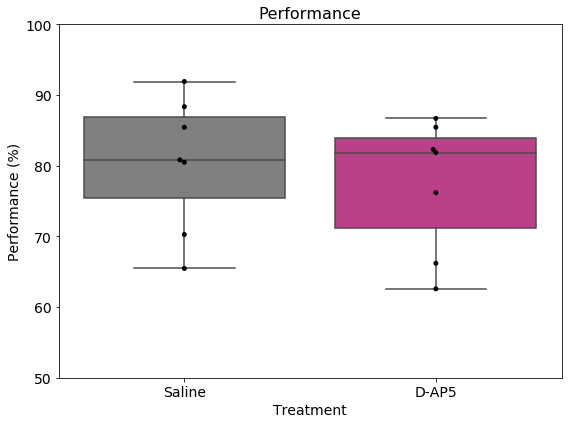

In [64]:
# Example usage (assuming 'df_post_AP5' is your DataFrame):
plot_performance(saline_df_post_ap5, last_ap5_df)

In [70]:
# filter the dataframes for ExperimentalGroup == 'Saline' and Protocol == 'Auditory'
saline_auditory = df[(df['ExperimentalGroup'] == 'Saline') & (df['Protocol'] == 'Auditory')]

# filter the dataframes for CumulativeTrialByProtocol == 3000
saline_auditory_3000 = saline_auditory[saline_auditory['CumulativeTrialNumberByProtocol'] == 3000]


In [94]:
saline_3000_dates = saline_auditory_3000['FullSessionTime'].values
print(saline_3000_dates)
saline_mice = saline_auditory_3000['AnimalID'].values
# print(saline_mice)

['2023-08-16T14:23:00.000000000' '2023-08-15T14:56:00.000000000'
 '2023-08-15T14:56:00.000000000' '2023-08-16T14:57:00.000000000'
 '2023-08-15T15:43:00.000000000']


In [89]:
# filter the dataframe for AnimalID in saline_mice and FullSessionTime in saline_3000_dates
saline_3000 = df[(df['AnimalID'].isin(saline_mice)) & (df['FullSessionTime'].isin(saline_3000_dates))]


  AnimalID  Performance
0    SP132    97.876858
1    SP134    89.749431
2    SP135    86.092715
3    SP136    94.417476
4    SP137    91.511936


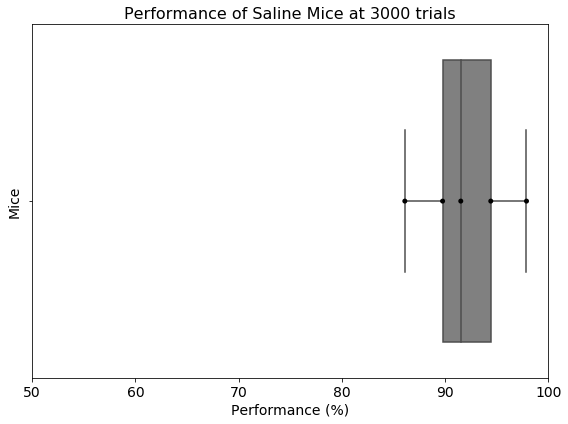

In [ ]:
# plot performance of saline_3000 

perf = saline_3000.groupby(['AnimalID'])['FirstPokeCorrect'].sum() / \
           saline_3000.groupby(['AnimalID'])['FirstPokeCorrect'].count() * 100
perf = perf.reset_index()
perf.columns = ['AnimalID', 'Performance']

print(perf)


In [ ]:
# all dates for saline mice[0]
saline_dates_132 = df[(df['AnimalID'] == 'SP132') & (df['ExperimentalGroup'] == 'Saline')]['FullSessionTime'].values

print(saline_dates_132)

# find the date that occurs after saline_3000_dates[0]
saline_dates_132_after_3000 = [date for date in saline_dates_132 if date > saline_3000_dates[0]][0]
print(saline_dates_132_after_3000)


['2023-08-05T14:45:00.000000000' '2023-08-05T14:45:00.000000000'
 '2023-08-05T14:45:00.000000000' ... '2023-08-18T14:16:00.000000000'
 '2023-08-18T14:16:00.000000000' '2023-08-18T14:16:00.000000000']
2023-08-17T15:01:00.000000000
2023-08-16T14:23:00.000000000


In [103]:
# iterate over saline_mice and saline_3000_dates to find the date that occurs after each date in saline_3000_dates
saline_dates_after_3000 = []

for mouse, date in zip(saline_mice, saline_3000_dates):
    date_after_3000 = df[(df['AnimalID'] == mouse) & (df['FullSessionTime'] > date)]['FullSessionTime'].values[0]
    saline_dates_after_3000.append(date_after_3000)

print(saline_dates_after_3000)

[numpy.datetime64('2023-08-17T15:01:00.000000000'), numpy.datetime64('2023-08-16T14:23:00.000000000'), numpy.datetime64('2023-08-16T14:23:00.000000000'), numpy.datetime64('2023-08-17T15:51:00.000000000'), numpy.datetime64('2023-08-16T15:05:00.000000000')]


/home/sthitapati/anaconda3/envs/behav/lib/python3.7/site-packages/ipykernel_launcher.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


   Treatment AnimalID  Performance
0      D-AP5    SP132    97.823834
1      D-AP5    SP134    90.239044
2      D-AP5    SP135    89.189189
3      D-AP5    SP136    96.296296
4      D-AP5    SP137    95.765159
5     Saline    SP120    85.439560
6     Saline    SP121    80.833333
7     Saline    SP122    80.503145
8     Saline    SP126    70.276008
9     Saline    SP138    88.359788
10    Saline    SP139    91.916168
11    Saline    SP140    65.472313
Data saved to './performance_data.csv'
t-statistic: -2.9508007449216045
p-value: 0.014514760600353062


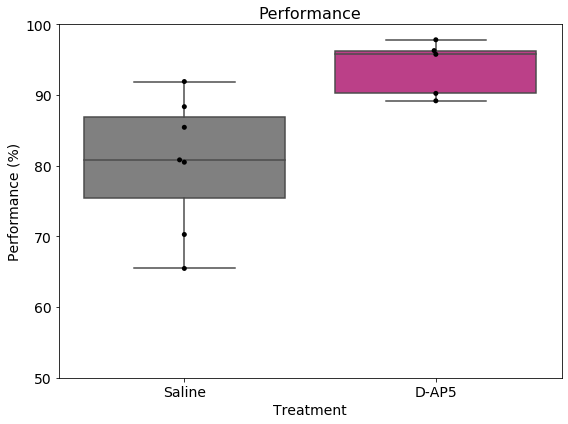

In [109]:
# filter the dataframe for AnimalID in saline_mice and FullSessionTime in saline_dates_after_3000
saline_after_3000 = df[(df['AnimalID'].isin(saline_mice)) & (df['FullSessionTime'].isin(saline_dates_after_3000))]

# plot performance of saline_after_3000
perf = saline_after_3000.groupby(['AnimalID'])['FirstPokeCorrect'].sum() / \
           saline_after_3000.groupby(['AnimalID'])['FirstPokeCorrect'].count() * 100
perf = perf.reset_index()
perf.columns = ['AnimalID', 'Performance']

plot_performance(saline_df_post_ap5, saline_after_3000)
